# The money figure: noisy single-SQS vs. learned Boltzmann average

The generic ML problem this project solves: estimate an expensive expectation
with a learned surrogate instead of a single noisy sample. Concretely, a single
SQS draws one oxygen-vacancy arrangement at random and reports its relaxed
energy as "the" `G(v)`. But arrangements at the same `(composition, v)` have
genuinely different energies (about **1.0-1.3 eV of spread** in the real data
below), so that one draw is noisy, worst exactly where it matters (high `v`,
reducing conditions). The physically correct quantity is the Boltzmann-weighted
configurational average, and a model that scores arrangements for free makes it
cheap.

Everything here runs on **real MACE-MPA-0-labeled data** (the factory v3
export): 30 training compositions with 40 relaxed arrangements each, plus two
**held-out** compositions sampled densely (8 vacancy levels x 60 arrangements)
as the brute-force reference. The model is the package's E(3)-equivariant GNN,
trained on the 30 training compositions only
(`EquivariantGNN(epochs=600, device="cuda")`, about 3 GPU-minutes).

Reproducing this notebook needs two gitignored local files: the dataset
`data/full/factory_v3.json` (built by `scripts/generate_factory_data.py`) and
the checkpoint `data/full/egnn_v3.json` (+ `.pt`). Outputs are committed, so
the rendered results stay viewable without them.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from vacancy_gnn.data.factory import load_factory_export
from vacancy_gnn.data.featurize import build_graph
from vacancy_gnn.evaluate import evaluate
from vacancy_gnn.metrics import free_energy_convergence
from vacancy_gnn.models.egnn import EquivariantGNN
from vacancy_gnn.physics.boltzmann import free_energy
from vacancy_gnn.physics.constants import T_FR

export = load_factory_export(Path("../data/full/factory_v3.json"))
model = EquivariantGNN.load(Path("../data/full/egnn_v3.json"))
reference = export.reference

graphs = [build_graph(a, cutoff=5.0) for a in reference.arrangements]
y_true = np.array([a.energy_ev for a in reference.arrangements])
y_pred = model.predict(graphs)
compositions = np.array([a.composition for a in reference.arrangements])
v_levels = np.array([a.v for a in reference.arrangements])

print(f"training compositions: {len(set(export.train.compositions()))}")
print(
    f"reference: {len(reference)} arrangements over "
    f"{len(set(compositions))} held-out compositions"
)

training compositions: 30
reference: 960 arrangements over 2 held-out compositions


## Calibrate the per-composition offset (8 oracle calls)

On a composition the model has never seen, its absolute energies are off by a
near-constant per-composition offset (a few eV here): the composition
reference must extrapolate to the new species mix. That constant is harmless
to every physics deliverable -- Boltzmann weights, arrangement ranking, and
`Delta G` across `v` are all invariant to it -- and pinning it costs almost
nothing: **one oracle label per vacancy level** (8 calls per composition,
versus 480 to brute-force the same `G(v)` curve). The parity gap below shows
how much of the raw error is that one constant.


In [2]:
offsets: dict[str, float] = {}
calibration_calls = 0
for comp in np.unique(compositions):
    mask = compositions == comp
    idx = [
        int(np.flatnonzero(mask & (v_levels == v))[0])
        for v in np.unique(v_levels[mask])
    ]
    offsets[comp] = float((y_pred[idx] - y_true[idx]).mean())
    calibration_calls += len(idx)

y_cal = y_pred - np.array([offsets[c] for c in compositions])

print(f"raw parity MAE:        {np.abs(y_pred - y_true).mean():.3f} eV")
print(
    f"calibrated parity MAE: {np.abs(y_cal - y_true).mean():.3f} eV "
    f"({calibration_calls} oracle calls total)"
)
for comp, offset in offsets.items():
    print(f"  {comp}: offset {offset:+.3f} eV")

raw parity MAE:        3.231 eV
calibrated parity MAE: 1.134 eV (16 oracle calls total)
  Al4Cr1Cu7Fe11Mn5Sn2V5Zr1O48-factory-017: offset -3.137 eV
  Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016: offset -4.026 eV


## The figure

One held-out `(composition, v)` group, 60 brute-force labels:

- **Red points**: `G(v)` from single independent SQS draws (one true label
  each) -- the status quo, and the noise this project exists to remove.
- **Blue line**: the Boltzmann average over the calibrated GNN predictions as
  more arrangements are folded into the sum; the band is +/- 1 standard
  deviation over the random order they are added in. Every point on the curve
  costs zero extra oracle calls.
- **Dashed line**: the brute-force truth from all 60 labels.

The blue curve settles at its own asymptote within a few arrangements; the
residual gap to truth is the model's real within-group error on a held-out
composition, reported honestly rather than tuned away.


Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016, v=4: brute-force truth G(v) = -556.619 eV


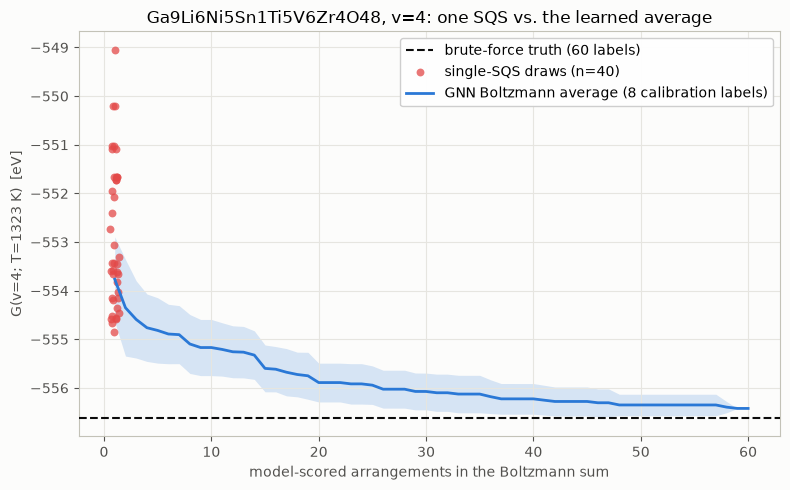

In [3]:
COMP = "Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016"
V = 4
group = np.flatnonzero((compositions == COMP) & (v_levels == V))
true_group = y_true[group]
pred_group = y_cal[group]
truth = free_energy(true_group, T_FR)
print(f"{COMP}, v={V}: brute-force truth G(v) = {truth:.3f} eV")

rng = np.random.default_rng(42)
n_draws = 40
single_sqs = rng.choice(true_group, size=n_draws, replace=True)

sizes = np.arange(1, len(group) + 1)
curves = np.stack(
    [
        free_energy_convergence(pred_group, T_FR, sample_sizes=sizes, seed=s)[1]
        for s in range(20)
    ]
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.axhline(
    truth,
    color="#0b0b0b",
    linestyle="--",
    linewidth=1.5,
    label="brute-force truth (60 labels)",
    zorder=5,
)
ax.scatter(
    1 + rng.uniform(-0.4, 0.4, size=n_draws),
    single_sqs,
    s=32,
    color="#e34948",
    alpha=0.75,
    linewidths=0,
    label=f"single-SQS draws (n={n_draws})",
    zorder=4,
)
ax.plot(
    sizes,
    curves.mean(axis=0),
    color="#2a78d6",
    linewidth=2,
    label="GNN Boltzmann average (8 calibration labels)",
    zorder=6,
)
ax.fill_between(
    sizes,
    curves.mean(axis=0) - curves.std(axis=0),
    curves.mean(axis=0) + curves.std(axis=0),
    color="#2a78d6",
    alpha=0.18,
    linewidth=0,
)
ax.set_xlabel("model-scored arrangements in the Boltzmann sum", color="#52514e")
ax.set_ylabel(f"G(v={V}; T={T_FR:.0f} K)  [eV]", color="#52514e")
ax.set_title(f"{COMP.split('-')[0]}, v={V}: one SQS vs. the learned average")
ax.grid(color="#e6e5e0", linewidth=0.8, zorder=0)
ax.tick_params(colors="#52514e")
for spine in ax.spines.values():
    spine.set_color("#c3c2b7")
ax.legend(loc="upper right", framealpha=0.95)
fig.tight_layout()
fig.savefig("money_figure.png", dpi=150, bbox_inches="tight")
plt.show()

## Why the average, not the lowest arrangement (PLAN.md Section 2.1)

The `T -> 0` limit of the Boltzmann sum is exactly the lowest-energy
arrangement. The harness reports, per composition, how far that limit departs
from the reactor-temperature average -- the "min-vs-average divergence" that
flags entropy-dominated groups where taking the minimum would misrank the
result.

Honest caveats, so the figure is read correctly:

- The per-composition offset is real (a few eV on unseen compositions) and is
  pinned here with 8 oracle labels; without calibration the curve would sit
  offset from truth by that constant. The `evaluate` CLI reports raw and
  offset-corrected parity side by side for exactly this reason.
- The GNN's within-group error is genuine model error on held-out
  compositions (about 0.8-1.0 eV MAE per arrangement, Spearman ~0.45 against
  a 1.0-1.3 eV label spread). Averaging is what buys the tight `G(v)`; the
  per-arrangement ranking is useful but far from perfect at this data scale.
- Everything assumes the vacancy configurations equilibrate at reactor
  temperature; if kinetics freeze the arrangement distribution, the
  Boltzmann weighting (and any single-SQS estimate) is an approximation.


In [4]:
report = evaluate(model, reference, reactor_temperature=T_FR, train=export.train)

print(f"parity: MAE={report.parity.mae:.3f} eV  RMSE={report.parity.rmse:.3f} eV")
print(
    "parity (per-composition offset removed): "
    f"MAE={report.parity.offset_corrected_mae:.3f} eV  "
    f"RMSE={report.parity.offset_corrected_rmse:.3f} eV"
)
for warning in report.out_of_hull_warnings:
    print(f"warning: {warning}")
if not report.out_of_hull_warnings:
    print("out-of-hull check: both reference compositions inside the training hull")
print()
for div in report.min_vs_average:
    label = "entropy-dominated" if div.entropy_dominated else "min-dominated"
    print(
        f"{div.composition} v={div.v}: G(T->0)={div.g_zero_t:.3f} eV  "
        f"G(T_reactor)={div.g_reactor_t:.3f} eV  ({label})"
    )

parity: MAE=3.231 eV  RMSE=3.545 eV
parity (per-composition offset removed): MAE=1.118 eV  RMSE=1.451 eV
out-of-hull check: both reference compositions inside the training hull

Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=0: G(T->0)=-594.093 eV  G(T_reactor)=-594.106 eV  (min-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=1: G(T->0)=-585.112 eV  G(T_reactor)=-585.113 eV  (min-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=2: G(T->0)=-575.081 eV  G(T_reactor)=-575.109 eV  (min-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=3: G(T->0)=-566.388 eV  G(T_reactor)=-566.390 eV  (min-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=4: G(T->0)=-556.619 eV  G(T_reactor)=-556.619 eV  (min-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=5: G(T->0)=-547.745 eV  G(T_reactor)=-547.773 eV  (min-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=6: G(T->0)=-536.900 eV  G(T_reactor)=-536.993 eV  (entropy-dominated)
Ga9Li6Ni5Sn1Ti5V6Zr4O48-factory-016 v=7: G(T->0)=-528.358 eV  G(T_reactor)=-528.359 eV  (m